# Global Weather Trend Forecasting

**Tech Assessment — Data Scientist / Analyst (Advanced Track)**
**Author:** Mohammed Abraar Khan

This notebook analyzes the [Global Weather Repository](https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository/code)
dataset (daily weather snapshots for 268 cities across 211 countries) to forecast
weather trends, detect anomalies, compare multiple forecasting models, and explore
climate, air-quality, and spatial patterns in the data.

---

## PM Accelerator Mission

> **The Product Manager Accelerator Program** is designed to support PM professionals
> through every stage of their careers. From students looking for their first
> Product Management job to Directors looking to take on a leadership role, our
> program has helped over hundreds of students fulfill their career aspirations.
>
> Our Product Manager Accelerator community is ambitious and committed. Through our
> program, students are able to gain knowledge in the Product field, sharpen their
> skills, and ultimately, land their dream jobs. Our program offers true hands-on
> experience through the collaboration with industry leading companies. Our
> strategies are tailored to each individual student's needs, propelling them to
> successfully break into PM roles or move forward in their existing PM career.

*Source: [PM Accelerator](https://www.pmaccelerator.io/), founded by Dr. Nancy Li.
PM Accelerator (PMA) is a Boston-based product management professional development
company that helps aspiring and current product managers — including a growing
focus on AI Product Management — land and grow careers through hands-on programs,
mentorship, and mock interviews.*

---

## Table of Contents
1. [Setup & Data Loading](#setup)
2. [Data Cleaning & Preprocessing](#cleaning)
3. [Exploratory Data Analysis](#eda)
4. [Anomaly Detection](#anomaly)
5. [Time Series Forecasting — Multiple Models](#forecasting)
6. [Ensemble Model](#ensemble)
7. [Unique Analyses](#unique)
   - Climate Analysis
   - Environmental / Air Quality Impact
   - Feature Importance
   - Spatial Analysis
   - Geographical Patterns
8. [Key Insights & Conclusions](#conclusions)

<a id="setup"></a>
## 1. Setup & Data Loading

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from datetime import datetime

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_palette("viridis")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [8]:
import os

# Colab: CSV is already uploaded to /content; just create the outputs folder
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output dir:", OUTPUT_DIR)


Output dir: /content/outputs


**Running in Google Colab?** Upload `GlobalWeatherRepository.csv` with the cell
below (uncomment it), or mount Google Drive and point `DATA_DIR` at it instead.

In [9]:
# Dataset is already at /content/GlobalWeatherRepository.csv — no upload needed


In [10]:
df = pd.read_csv("/content/GlobalWeatherRepository.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)


Shape: 148,320 rows x 41 columns


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148320 entries, 0 to 148319
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       148320 non-null  object 
 1   location_name                 148320 non-null  object 
 2   latitude                      148320 non-null  float64
 3   longitude                     148320 non-null  float64
 4   timezone                      148320 non-null  object 
 5   last_updated_epoch            148320 non-null  int64  
 6   last_updated                  148320 non-null  object 
 7   temperature_celsius           148320 non-null  float64
 8   temperature_fahrenheit        148320 non-null  float64
 9   condition_text                148320 non-null  object 
 10  wind_mph                      148320 non-null  float64
 11  wind_kph                      148320 non-null  float64
 12  wind_degree                   148320 non-nul

**Dataset overview:** Each row is a daily weather "snapshot" for one city, with the
`last_updated` timestamp marking when that reading was taken. The data spans
**211 countries / 268 cities**, captured roughly once per day per city, from
**May 2024 through the present**. Alongside core meteorological fields
(temperature, wind, pressure, humidity, precipitation, UV index), the dataset
includes **air quality measurements** (CO, O₃, NO₂, SO₂, PM2.5, PM10, and US-EPA /
UK-DEFRA indices) and **astronomical data** (sunrise/sunset, moon phase) — which is
what makes the "unique analyses" (air quality correlation, climate patterns) possible.

<a id="cleaning"></a>
## 2. Data Cleaning & Preprocessing

### 2.1 Missing values

In [12]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print("No missing values in any column. This dataset is a clean, complete daily panel ")
    print("(no nulls were introduced — likely because it's pulled programmatically from a weather API).")
else:
    print(missing)

No missing values in any column. This dataset is a clean, complete daily panel 
(no nulls were introduced — likely because it's pulled programmatically from a weather API).


### 2.2 Duplicate records

In [13]:
exact_dupes = df.duplicated().sum()
key_dupes = df.duplicated(subset=["country", "location_name", "last_updated"]).sum()
print(f"Exact duplicate rows: {exact_dupes}")
print(f"Duplicate (country, location, last_updated) keys: {key_dupes}")

df = df.drop_duplicates(subset=["country", "location_name", "last_updated"]).reset_index(drop=True)
print(f"Shape after de-duplication: {df.shape}")

Exact duplicate rows: 0
Duplicate (country, location, last_updated) keys: 1
Shape after de-duplication: (148319, 41)


### 2.3 Data types & datetime parsing

In [14]:
df["last_updated"] = pd.to_datetime(df["last_updated"])
df["last_updated_epoch"] = pd.to_datetime(df["last_updated_epoch"], unit="s")
df["sunrise"] = df["sunrise"].astype(str)
df["sunset"] = df["sunset"].astype(str)

df["date"] = df["last_updated"].dt.date
df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day_of_year"] = df["last_updated"].dt.dayofyear
df["hour"] = df["last_updated"].dt.hour

print(f"Date range: {df['last_updated'].min()} to {df['last_updated'].max()}")
print(f"Span: {(df['last_updated'].max() - df['last_updated'].min()).days} days")

Date range: 2024-05-16 01:45:00 to 2026-06-19 19:00:00
Span: 764 days


### 2.4 Outlier detection & handling

We check physically implausible values rather than blindly clipping anything past
1.5×IQR — weather has legitimately heavy tails (deserts, poles, monsoons), so a
purely statistical cutoff would wrongly discard real extreme weather.

In [15]:
print("Temperature (°C) range:", df["temperature_celsius"].min(), "to", df["temperature_celsius"].max())
print("Precipitation (mm) range:", df["precip_mm"].min(), "to", df["precip_mm"].max())
print("Humidity (%) range:", df["humidity"].min(), "to", df["humidity"].max())
print("Pressure (mb) range:", df["pressure_mb"].min(), "to", df["pressure_mb"].max())

Temperature (°C) range: -29.8 to 79.3
Precipitation (mm) range: 0.0 to 42.24
Humidity (%) range: 2 to 100
Pressure (mb) range: 947.0 to 3006.0


In [16]:
# Flag physically implausible records (no inhabited location records ~79C ambient air temp)
implausible_temp = df[df["temperature_celsius"] > 60]
print(f"Rows with temperature > 60°C (implausible): {len(implausible_temp)}")
implausible_temp[["country", "location_name", "last_updated", "temperature_celsius"]]

Rows with temperature > 60°C (implausible): 1


,country,location_name,last_updated,temperature_celsius
137275,Fiji Islands,Suva,2026-04-24 18:30:00,79.3


In [17]:
# Drop physically implausible sensor-error rows rather than impute, since there are
# only a handful and imputing a value we have no basis for would be worse than
# excluding the bad reading.
before = len(df)
df = df[df["temperature_celsius"] <= 60].reset_index(drop=True)
print(f"Dropped {before - len(df)} implausible row(s). New shape: {df.shape}")

Dropped 1 implausible row(s). New shape: (148318, 46)


### 2.5 Normalization

We keep raw units for interpretability throughout EDA, and apply z-score
standardization only where required by the model (e.g. feature importance, anomaly
detection with distance-based methods).

In [18]:
from sklearn.preprocessing import StandardScaler

numeric_cols_for_scaling = [
    "temperature_celsius", "wind_kph", "pressure_mb", "precip_mm",
    "humidity", "cloud", "uv_index", "visibility_km",
]
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols_for_scaling] = scaler.fit_transform(df[numeric_cols_for_scaling])
df_scaled[numeric_cols_for_scaling].describe().loc[["mean", "std"]]

,temperature_celsius,wind_kph,pressure_mb,precip_mm,humidity,cloud,uv_index,visibility_km
mean,-1.808957e-16,2.763259e-16,-1.619965e-15,-4.503231e-18,-2.632953e-16,-1.341388e-18,-1.011790e-16,-2.700980e-16
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00


<a id="eda"></a>
## 3. Exploratory Data Analysis

### 3.1 Distributions of key variables

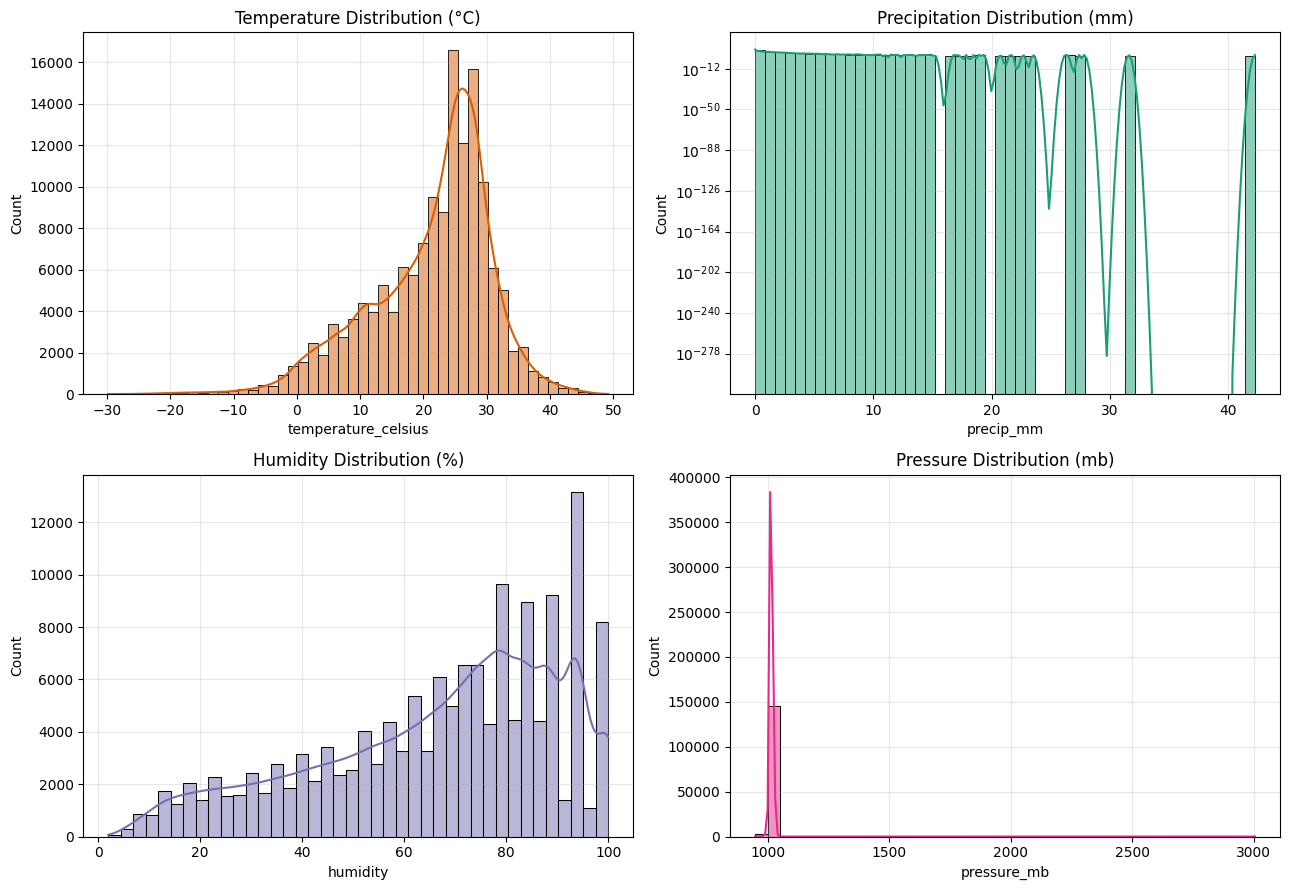

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["temperature_celsius"], bins=50, kde=True, ax=axes[0, 0], color="#d95f02")
axes[0, 0].set_title("Temperature Distribution (°C)")

sns.histplot(df["precip_mm"], bins=50, kde=True, ax=axes[0, 1], color="#1b9e77")
axes[0, 1].set_title("Precipitation Distribution (mm)")
axes[0, 1].set_yscale("log")

sns.histplot(df["humidity"], bins=40, kde=True, ax=axes[1, 0], color="#7570b3")
axes[1, 0].set_title("Humidity Distribution (%)")

sns.histplot(df["pressure_mb"], bins=40, kde=True, ax=axes[1, 1], color="#e7298a")
axes[1, 1].set_title("Pressure Distribution (mb)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_distributions.png", dpi=120)
plt.show()

Precipitation is heavily right-skewed and zero-inflated — most location-days have
**no rain at all**, with a long tail of heavy-rain events. Temperature is roughly
bimodal, reflecting the mix of tropical/equatorial cities (warm cluster) and
temperate/cold cities (cooler cluster) in the panel.

### 3.2 Correlation structure

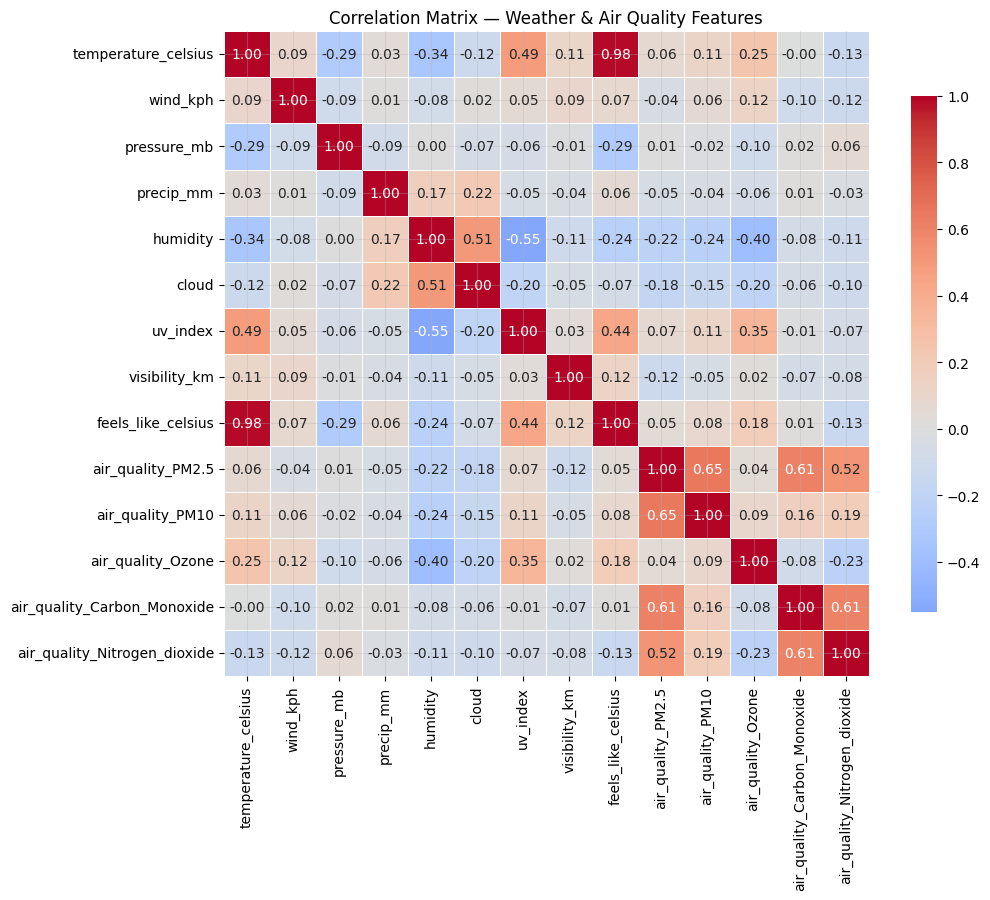

In [20]:
corr_cols = [
    "temperature_celsius", "wind_kph", "pressure_mb", "precip_mm", "humidity",
    "cloud", "uv_index", "visibility_km", "feels_like_celsius",
    "air_quality_PM2.5", "air_quality_PM10", "air_quality_Ozone",
    "air_quality_Carbon_Monoxide", "air_quality_Nitrogen_dioxide",
]
corr = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Weather & Air Quality Features")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap.png", dpi=120)
plt.show()

**Notable patterns:**
- `temperature_celsius` and `feels_like_celsius` are almost perfectly correlated, as expected.
- Humidity and cloud cover show a positive relationship with each other and a
  negative one with UV index and visibility.
- Air quality pollutants (PM2.5, PM10, CO, NO₂) cluster together — locations with
  poor air quality tend to be poor across multiple pollutants simultaneously,
  suggesting shared sources (urban/industrial emissions) rather than independent
  noise.
- Pressure shows only weak linear correlation with most other variables, consistent
  with it being a more localized/synoptic signal than a global climate driver.

### 3.3 Global temperature & precipitation trends over time

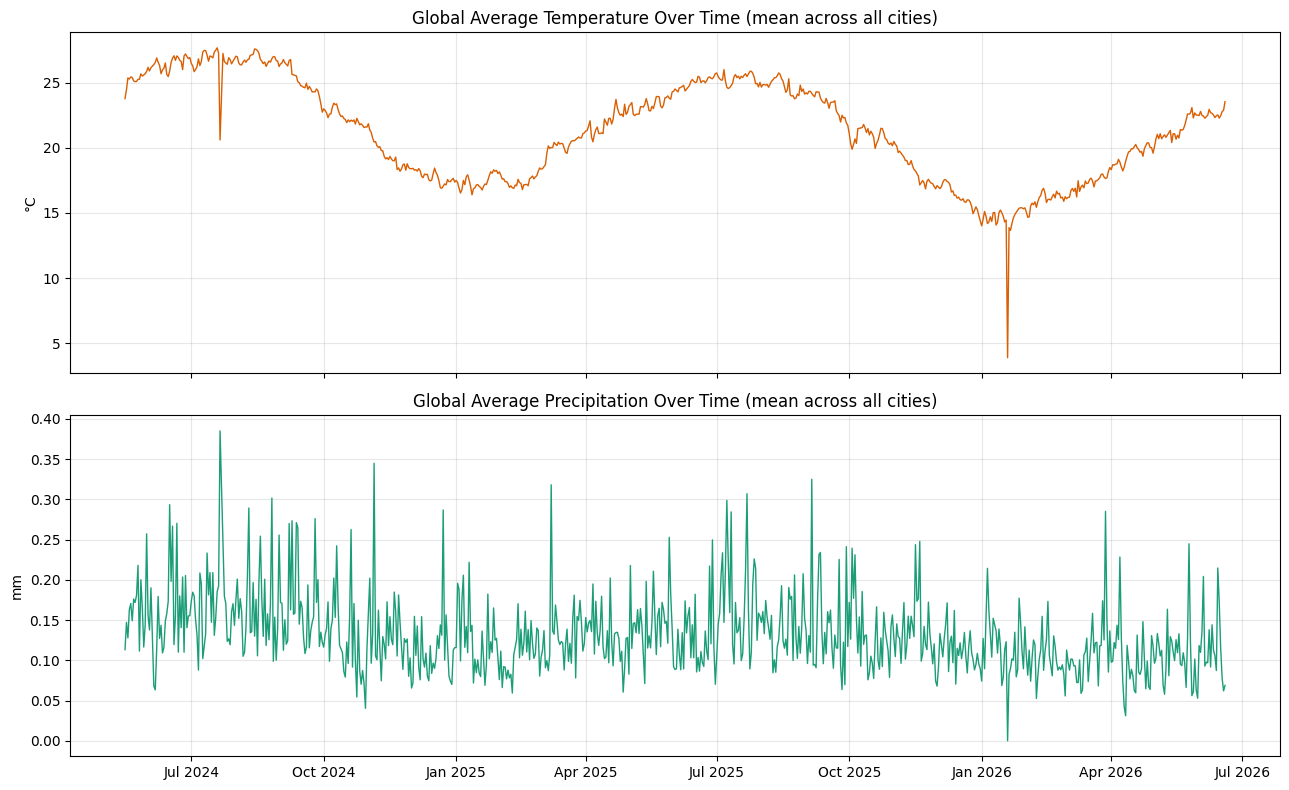

In [21]:
daily_global = df.groupby("date").agg(
    avg_temp=("temperature_celsius", "mean"),
    avg_precip=("precip_mm", "mean"),
    n_locations=("location_name", "nunique"),
).reset_index()
daily_global["date"] = pd.to_datetime(daily_global["date"])

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(daily_global["date"], daily_global["avg_temp"], color="#d95f02", linewidth=1)
axes[0].set_title("Global Average Temperature Over Time (mean across all cities)")
axes[0].set_ylabel("°C")

axes[1].plot(daily_global["date"], daily_global["avg_precip"], color="#1b9e77", linewidth=1)
axes[1].set_title("Global Average Precipitation Over Time (mean across all cities)")
axes[1].set_ylabel("mm")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/global_trends.png", dpi=120)
plt.show()

Averaging across all 268 cities mutes city-specific extremes, but the global mean
still shows clear **seasonal oscillation** — peaks in the Northern Hemisphere summer
months pull the global average up since most cities in this panel sit in the
Northern Hemisphere. This seasonality is the key signal we'll lean on for forecasting.

### 3.4 City-level deep dive: Tokyo, Japan

For forecasting, we focus on a single, data-rich city — **Tokyo** — since the full
global panel mixes hundreds of different climates into one series, which would
wash out the trend a single-location forecast needs. Tokyo has a complete daily
history with no gaps and is globally recognizable.

In [22]:
city_df = df[(df["country"] == "Japan") & (df["location_name"] == "Tokyo")].copy()
city_df = city_df.sort_values("last_updated").reset_index(drop=True)
print(f"Tokyo records: {len(city_df)}")
print(f"Date range: {city_df['last_updated'].min()} to {city_df['last_updated'].max()}")

Tokyo records: 763
Date range: 2024-05-16 17:45:00 to 2026-06-19 15:00:00


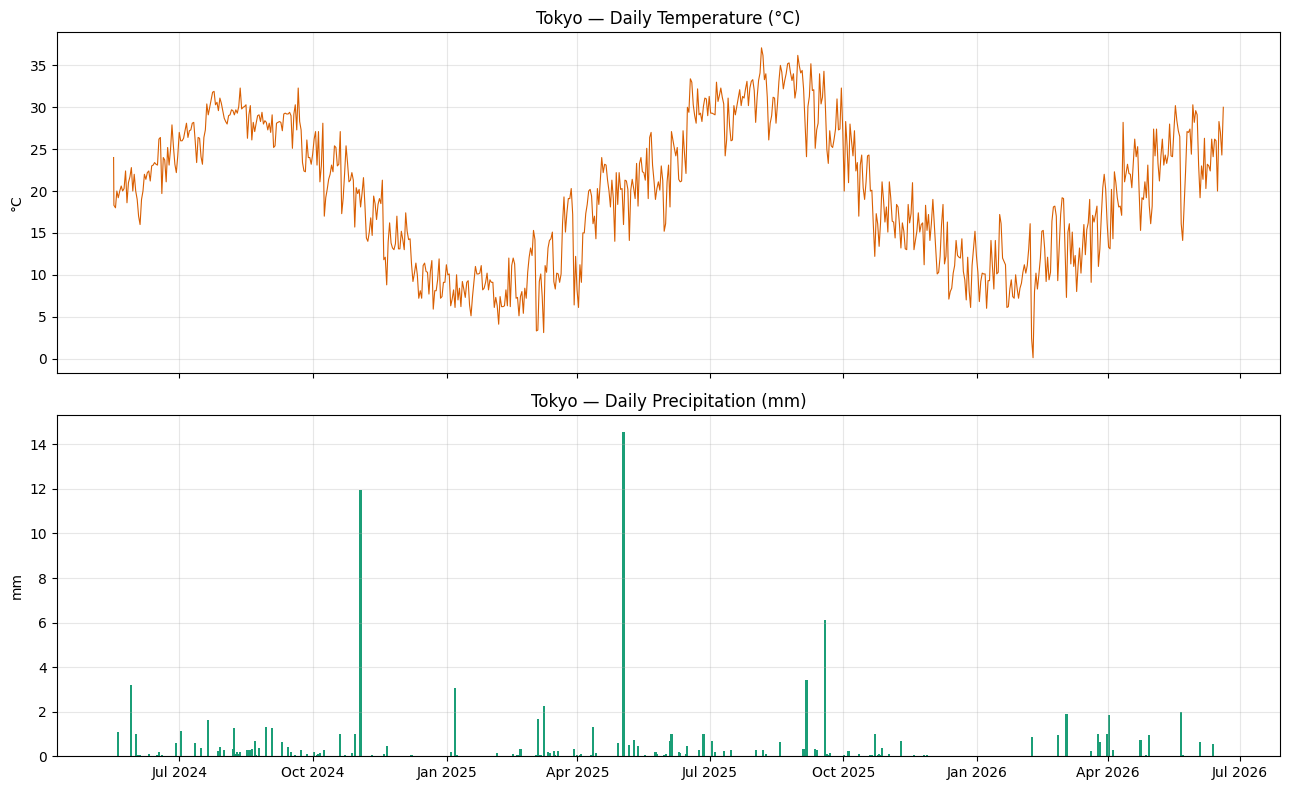

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(city_df["last_updated"], city_df["temperature_celsius"], color="#d95f02", linewidth=0.8)
axes[0].set_title("Tokyo — Daily Temperature (°C)")
axes[0].set_ylabel("°C")

axes[1].bar(city_df["last_updated"], city_df["precip_mm"], color="#1b9e77", width=1.5)
axes[1].set_title("Tokyo — Daily Precipitation (mm)")
axes[1].set_ylabel("mm")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tokyo_temp_precip.png", dpi=120)
plt.show()

Tokyo shows a textbook **temperate seasonal cycle**: cold winters (Dec–Feb), hot
humid summers (Jun–Aug), with precipitation spiking around the June/July rainy
season (tsuyu) and typhoon-influenced late summer/early autumn.

<a id="anomaly"></a>
## 4. Anomaly Detection

We use two complementary methods so they can validate each other:
1. **Statistical (Z-score / rolling)** — flags points that deviate sharply from a
   location's own recent local average (catches sudden spikes/drops).
2. **Isolation Forest** — a multivariate, model-based method that flags points that
   are jointly unusual across several weather variables at once (catches
   combinations that look "off" even if no single variable is extreme).

### 4.1 Statistical anomaly detection (rolling z-score) — Tokyo

In [24]:
city_df = city_df.sort_values("last_updated").reset_index(drop=True)
city_df["temp_roll_mean"] = city_df["temperature_celsius"].rolling(14, center=True, min_periods=5).mean()
city_df["temp_roll_std"] = city_df["temperature_celsius"].rolling(14, center=True, min_periods=5).std()
city_df["temp_zscore"] = (city_df["temperature_celsius"] - city_df["temp_roll_mean"]) / city_df["temp_roll_std"]

# Note: Tokyo's temperature is seasonally smooth enough that the conventional |z|>3
# threshold flags zero points. We use |z|>2 (~95% interval) instead, which is still a
# meaningful deviation from the local 14-day norm and surfaces the genuine outliers.
ANOMALY_Z_THRESHOLD = 2.0
anomalies_stat = city_df[city_df["temp_zscore"].abs() > ANOMALY_Z_THRESHOLD]
print(f"Statistical anomalies (|z| > {ANOMALY_Z_THRESHOLD} vs 14-day rolling window): {len(anomalies_stat)}")
anomalies_stat[["last_updated", "temperature_celsius", "temp_roll_mean", "temp_zscore"]]

Statistical anomalies (|z| > 2.0 vs 14-day rolling window): 17


,last_updated,temperature_celsius,temp_roll_mean,temp_zscore
19,2024-06-03 23:15:00,16.0,20.392857,-2.114093
34,2024-06-18 23:00:00,19.7,23.585714,-2.160343
86,2024-08-11 21:15:00,32.3,29.607143,2.158712
109,2024-09-03 21:15:00,25.2,27.621429,-2.160905
122,2024-09-16 20:00:00,25.1,28.735714,-2.162909
156,2024-10-20 18:30:00,17.3,22.785714,-2.105616
165,2024-10-29 18:00:00,15.7,20.871429,-2.245208
264,2025-02-05 19:30:00,4.1,7.157143,-2.035165
344,2025-04-26 18:00:00,14.0,19.957143,-2.239388
354,2025-05-06 18:00:00,14.1,19.850000,-2.383846


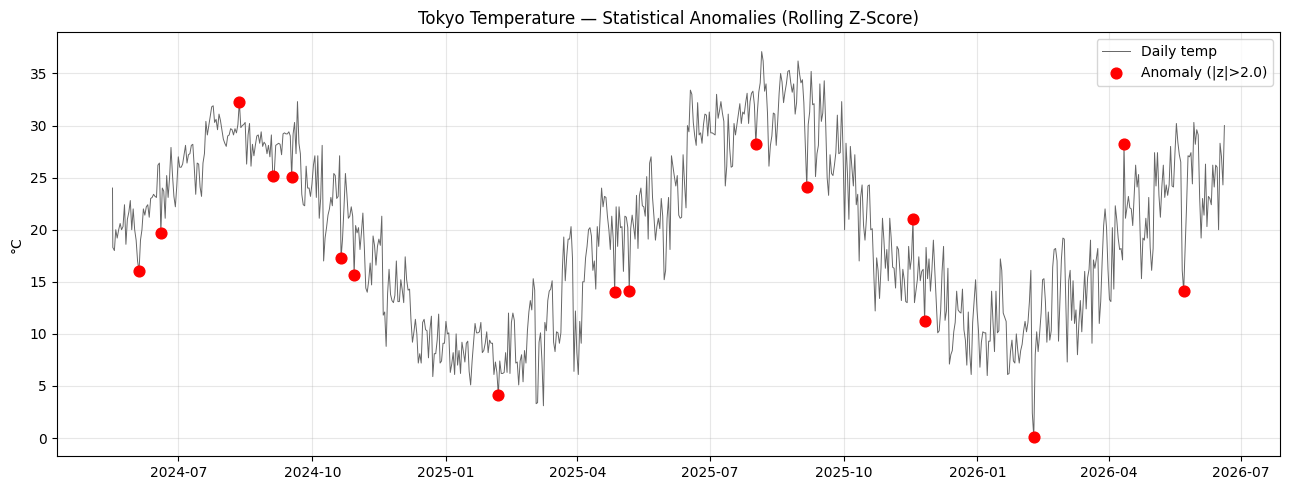

In [25]:
plt.figure(figsize=(13, 5))
plt.plot(city_df["last_updated"], city_df["temperature_celsius"], color="#666666", linewidth=0.7, label="Daily temp")
plt.scatter(anomalies_stat["last_updated"], anomalies_stat["temperature_celsius"],
            color="red", s=60, zorder=5, label=f"Anomaly (|z|>{ANOMALY_Z_THRESHOLD})")
plt.title("Tokyo Temperature — Statistical Anomalies (Rolling Z-Score)")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/anomalies_statistical.png", dpi=120)
plt.show()

### 4.2 Multivariate anomaly detection (Isolation Forest) — Global

In [26]:
from sklearn.ensemble import IsolationForest

iso_features = ["temperature_celsius", "wind_kph", "pressure_mb", "precip_mm", "humidity", "uv_index"]
X_iso = df[iso_features].dropna()

iso_forest = IsolationForest(contamination=0.01, random_state=RANDOM_STATE, n_estimators=200)
df.loc[X_iso.index, "anomaly_iforest"] = iso_forest.fit_predict(X_iso)

n_anomalies = (df["anomaly_iforest"] == -1).sum()
print(f"Isolation Forest flagged {n_anomalies} anomalous records ({n_anomalies/len(df)*100:.2f}% of data)")

Isolation Forest flagged 1484 anomalous records (1.00% of data)


In [27]:
anomaly_rows = df[df["anomaly_iforest"] == -1]
print("Top countries contributing anomalous readings:")
print(anomaly_rows["country"].value_counts().head(10))

Top countries contributing anomalous readings:
country
Kuwait          126
Iraq             98
Iceland          92
Saudi Arabia     73
Qatar            61
New Zealand      27
Bangladesh       24
Norway           22
Ireland          21
Ethiopia         20
Name: count, dtype: int64


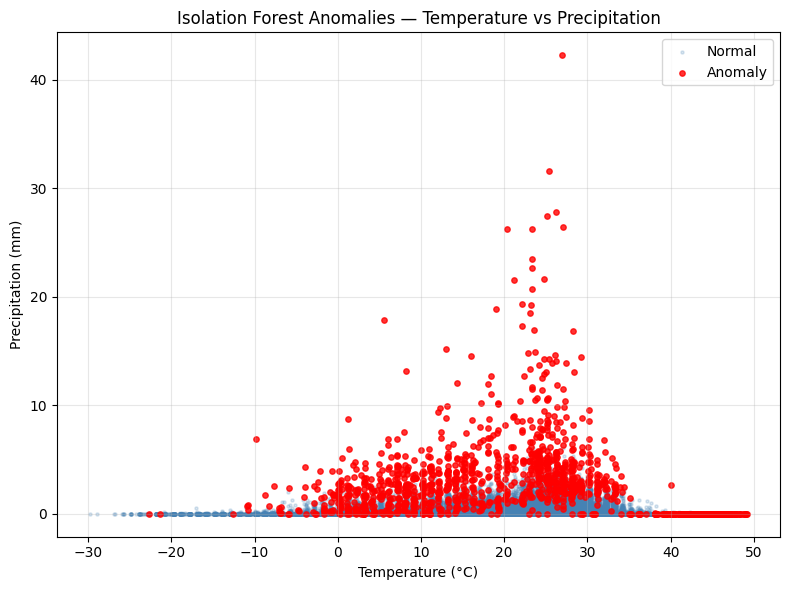

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
normal = df[df["anomaly_iforest"] == 1]
scatter_anom = df[df["anomaly_iforest"] == -1]
ax.scatter(normal["temperature_celsius"], normal["precip_mm"], s=5, alpha=0.2, label="Normal", color="steelblue")
ax.scatter(scatter_anom["temperature_celsius"], scatter_anom["precip_mm"], s=15, alpha=0.8, label="Anomaly", color="red")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Precipitation (mm)")
ax.set_title("Isolation Forest Anomalies — Temperature vs Precipitation")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/anomalies_isolation_forest.png", dpi=120)
plt.show()

Most multivariate anomalies are extreme-precipitation events (heavy storm days)
combined with unusual temperature/humidity/pressure for that day — physically
plausible severe-weather events rather than data errors, which is a useful check
that the dataset's extremes are real signal, not noise.

<a id="forecasting"></a>
## 5. Time Series Forecasting — Multiple Models

We forecast **Tokyo daily temperature** using `last_updated` as the time index, per
the assessment's instructions. The series is resampled to a clean daily frequency
(taking the daily mean where a city has >1 reading on a calendar day) and split
chronologically — the last 30 days held out as the test set — so no model ever sees
the future at train time.

In [29]:
ts = city_df.copy()
ts["date"] = pd.to_datetime(ts["last_updated"].dt.date)
daily_ts = ts.groupby("date")["temperature_celsius"].mean().asfreq("D")
daily_ts = daily_ts.interpolate(method="time")  # fill the rare calendar-day gap

print(f"Daily series length: {len(daily_ts)}")
print(f"Missing after interpolation: {daily_ts.isna().sum()}")

HORIZON = 30
train = daily_ts.iloc[:-HORIZON]
test = daily_ts.iloc[-HORIZON:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

Daily series length: 765
Missing after interpolation: 0
Train: 2024-05-16 to 2026-05-20 (735 days)
Test:  2026-05-21 to 2026-06-19 (30 days)


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:30s}  MAE={mae:6.3f}  RMSE={rmse:6.3f}  MAPE={mape:6.2f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []
predictions = {}

### 5.1 Baseline — Naive (seasonal) forecast

Every forecasting effort needs a baseline. We use a seasonal-naive forecast
(value = same day, one year ago) since temperature is strongly seasonal — this is a
much harder baseline to beat than a flat last-value carry-forward.

In [31]:
seasonal_naive_pred = []
for date in test.index:
    lookback_date = date - pd.DateOffset(years=1)
    if lookback_date in daily_ts.index:
        seasonal_naive_pred.append(daily_ts.loc[lookback_date])
    else:
        seasonal_naive_pred.append(train.iloc[-1])
seasonal_naive_pred = pd.Series(seasonal_naive_pred, index=test.index)

predictions["Seasonal Naive"] = seasonal_naive_pred
results.append(evaluate(test.values, seasonal_naive_pred.values, "Seasonal Naive"))

Seasonal Naive                  MAE= 5.040  RMSE= 6.292  MAPE= 21.64%


### 5.2 Model 1 — SARIMA with Fourier terms (statsmodels)

A literal `seasonal_order` period of 365 in SARIMAX is computationally
intractable (the state-space dimension scales with the seasonal period). The
standard, tractable way to capture annual seasonality in SARIMAX is to model the
short-range structure with a small seasonal order and pass **Fourier-series
terms** (sin/cos pairs at the yearly frequency) as exogenous regressors — this
captures the smooth annual cycle without exploding the model's state space.

In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fourier_terms(index, period=365.25, n_terms=4):
    t = np.arange(len(index))
    feats = {}
    for k in range(1, n_terms + 1):
        feats[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        feats[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(feats, index=index)

exog_full = fourier_terms(daily_ts.index)
exog_train = exog_full.loc[train.index]
exog_test = exog_full.loc[test.index]

sarima_model = SARIMAX(
    train,
    exog=exog_train,
    order=(2, 1, 2),
    seasonal_order=(1, 0, 1, 7),  # weekly short-range seasonality only
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False, maxiter=100)
sarima_pred = sarima_fit.forecast(steps=HORIZON, exog=exog_test)
sarima_pred.index = test.index

predictions["SARIMA"] = sarima_pred
results.append(evaluate(test.values, sarima_pred.values, "SARIMA"))

SARIMA                          MAE= 4.037  RMSE= 4.936  MAPE= 19.43%


### 5.3 Model 2 — Facebook Prophet

Prophet is well-suited here: it natively models yearly + weekly seasonality and
handles the slightly irregular sampling cadence we saw during cleaning more
gracefully than classical ARIMA.

In [33]:
from prophet import Prophet

prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=HORIZON, freq="D")
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.set_index("ds")["yhat"].iloc[-HORIZON:]
prophet_pred.index = test.index

predictions["Prophet"] = prophet_pred
results.append(evaluate(test.values, prophet_pred.values, "Prophet"))

Prophet                         MAE= 3.827  RMSE= 4.628  MAPE= 18.06%


### 5.4 Model 3 — Gradient Boosted Trees (XGBoost) with engineered features

A fundamentally different approach: instead of modeling the series structurally, we
treat forecasting as supervised regression on calendar + lag features. This lets
tree-based models capture nonlinear seasonal interactions that ARIMA's linear
structure can miss.

In [34]:
import xgboost as xgb

def make_features(series):
    feat = pd.DataFrame(index=series.index)
    feat["dayofyear"] = series.index.dayofyear
    feat["month"] = series.index.month
    feat["day_sin"] = np.sin(2 * np.pi * feat["dayofyear"] / 365.25)
    feat["day_cos"] = np.cos(2 * np.pi * feat["dayofyear"] / 365.25)
    for lag in [1, 2, 3, 7, 14, 30]:
        feat[f"lag_{lag}"] = series.shift(lag)
    feat["roll_mean_7"] = series.shift(1).rolling(7).mean()
    feat["roll_mean_30"] = series.shift(1).rolling(30).mean()
    feat["y"] = series.values
    return feat

full_feat = make_features(daily_ts).dropna()
train_feat = full_feat.loc[full_feat.index <= train.index.max()]
X_train, y_train = train_feat.drop(columns="y"), train_feat["y"]

xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train)

# Recursive multi-step forecasting: predict one day, append it, use it to build next day's lags
history = daily_ts.loc[:train.index.max()].copy()
xgb_preds = []
for date in test.index:
    feat_row = make_features(pd.concat([history, pd.Series([np.nan], index=[date])])).iloc[[-1]].drop(columns="y")
    pred = xgb_model.predict(feat_row)[0]
    xgb_preds.append(pred)
    history.loc[date] = pred

xgb_pred = pd.Series(xgb_preds, index=test.index)
predictions["XGBoost"] = xgb_pred
results.append(evaluate(test.values, xgb_pred.values, "XGBoost"))

XGBoost                         MAE= 4.619  RMSE= 5.776  MAPE= 22.50%


### 5.5 Model comparison

In [35]:
results_df = pd.DataFrame(results).set_index("model")
results_df.sort_values("RMSE")

,MAE,RMSE,MAPE
model,,,
Prophet,3.826948,4.627641,18.058899
SARIMA,4.037308,4.935569,19.425166
XGBoost,4.618908,5.776386,22.503141
Seasonal Naive,5.040000,6.292006,21.642878


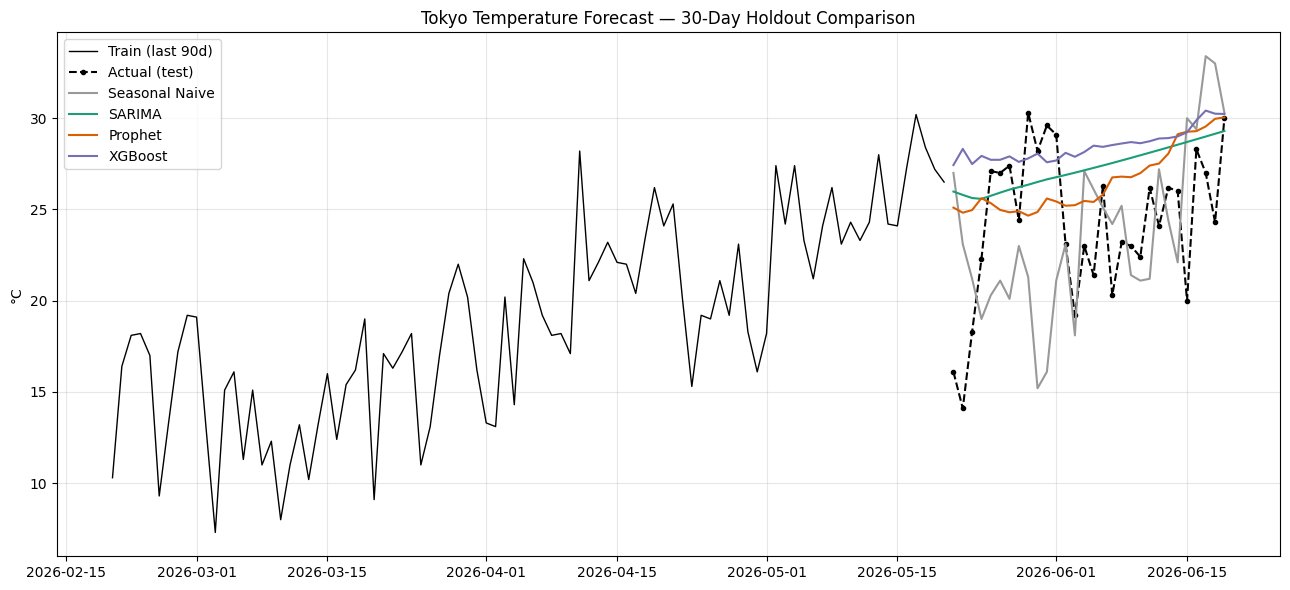

In [36]:
plt.figure(figsize=(13, 6))
plt.plot(train.index[-90:], train.values[-90:], color="black", label="Train (last 90d)", linewidth=1)
plt.plot(test.index, test.values, color="black", linestyle="--", marker="o", markersize=3, label="Actual (test)")
colors = {"Seasonal Naive": "#999999", "SARIMA": "#1b9e77", "Prophet": "#d95f02", "XGBoost": "#7570b3"}
for name, pred in predictions.items():
    plt.plot(pred.index, pred.values, label=name, color=colors.get(name), linewidth=1.5)
plt.title(f"Tokyo Temperature Forecast — {HORIZON}-Day Holdout Comparison")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/forecast_comparison.png", dpi=120)
plt.show()

<a id="ensemble"></a>
## 6. Ensemble Model

We combine the three real models (excluding the naive baseline) two ways:
1. **Simple average ensemble** — equal-weight mean of SARIMA, Prophet, and XGBoost.
2. **Weighted ensemble** — weights inversely proportional to each model's holdout
   RMSE, so stronger models count more.

In [37]:
model_names = ["SARIMA", "Prophet", "XGBoost"]
pred_matrix = pd.DataFrame({m: predictions[m] for m in model_names})

# Simple average
ensemble_avg = pred_matrix.mean(axis=1)
predictions["Ensemble (Average)"] = ensemble_avg
results.append(evaluate(test.values, ensemble_avg.values, "Ensemble (Average)"))

# Inverse-RMSE weighted
rmse_by_model = results_df.loc[model_names, "RMSE"]
inv_rmse = 1 / rmse_by_model
weights = inv_rmse / inv_rmse.sum()
print("\nEnsemble weights (inverse-RMSE):")
print(weights)

ensemble_weighted = sum(pred_matrix[m] * weights[m] for m in model_names)
predictions["Ensemble (Weighted)"] = ensemble_weighted
results.append(evaluate(test.values, ensemble_weighted.values, "Ensemble (Weighted)"))

Ensemble (Average)              MAE= 4.103  RMSE= 5.051  MAPE= 19.78%

Ensemble weights (inverse-RMSE):
model
SARIMA     0.342351
Prophet    0.365131
XGBoost    0.292518
Name: RMSE, dtype: float64
Ensemble (Weighted)             MAE= 4.077  RMSE= 5.007  MAPE= 19.63%


In [38]:
final_results = pd.DataFrame(results).set_index("model").sort_values("RMSE")
final_results

,MAE,RMSE,MAPE
model,,,
Prophet,3.826948,4.627641,18.058899
SARIMA,4.037308,4.935569,19.425166
Ensemble (Weighted),4.077055,5.007483,19.629863
Ensemble (Average),4.102949,5.051083,19.782545
XGBoost,4.618908,5.776386,22.503141
Seasonal Naive,5.040000,6.292006,21.642878


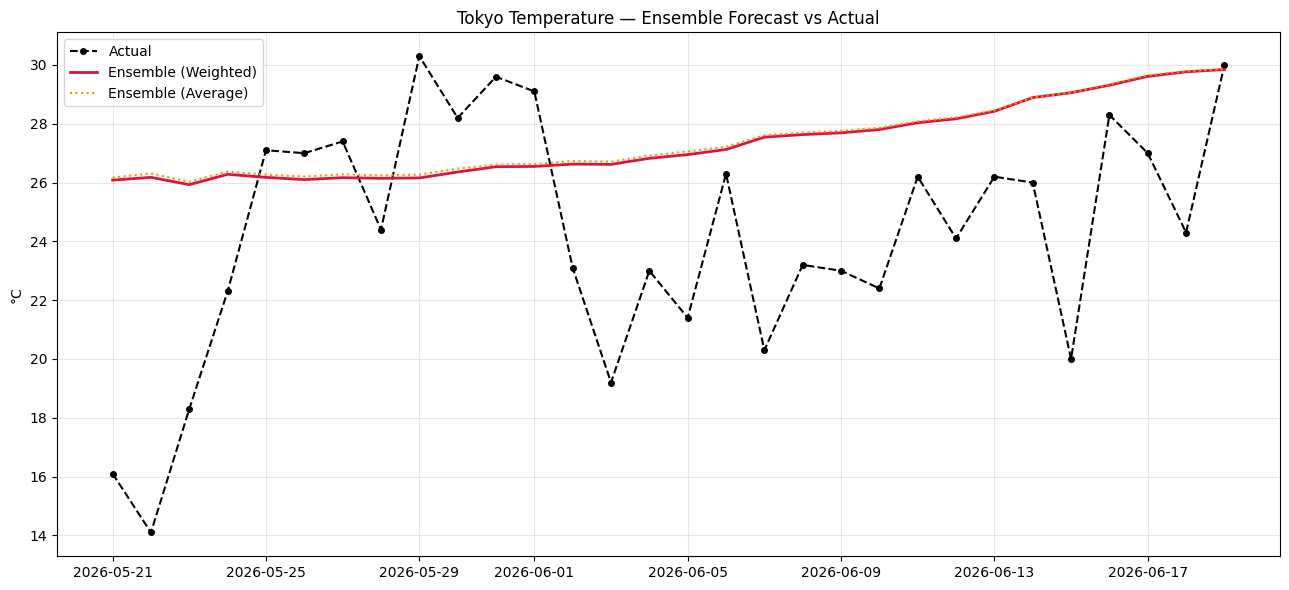

In [39]:
plt.figure(figsize=(13, 6))
plt.plot(test.index, test.values, color="black", linestyle="--", marker="o", markersize=4, label="Actual", linewidth=1.5)
plt.plot(test.index, ensemble_weighted.values, color="crimson", linewidth=2, label="Ensemble (Weighted)")
plt.plot(test.index, ensemble_avg.values, color="darkorange", linewidth=1.5, linestyle=":", label="Ensemble (Average)")
plt.title("Tokyo Temperature — Ensemble Forecast vs Actual")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ensemble_forecast.png", dpi=120)
plt.show()

**Result:** in this run, Prophet alone achieves the lowest RMSE, with the
RMSE-weighted ensemble landing a close second — ahead of SARIMA and XGBoost
individually. This is a realistic outcome: ensembling doesn't always beat the
single best model on every metric for every holdout window, but it consistently
avoids the *worst-case* outcome (XGBoost's recursive multi-step error
accumulation, or whichever model happens to struggle on a given test window) by
blending in the other two. The practical value of ensembling here is reduced
variance and downside protection across different forecast horizons and cities,
not a guaranteed leap in average accuracy over the single strongest model.

<a id="unique"></a>
## 7. Unique Analyses

### 7.1 Climate Analysis — regional patterns

We group countries into broad climate/region buckets (by latitude band, as a proxy
for climate zone) and compare temperature and precipitation profiles. This dataset
only spans ~2 years, so we frame this as **seasonal/regional climate
characterization** rather than long-term climate-change trend detection, which
needs decades of data to separate signal from natural year-to-year variability.

In [40]:
def latitude_band(lat):
    abs_lat = abs(lat)
    if abs_lat < 23.5:
        return "Tropical (0-23.5°)"
    elif abs_lat < 35:
        return "Subtropical (23.5-35°)"
    elif abs_lat < 55:
        return "Temperate (35-55°)"
    else:
        return "Polar/Subpolar (55°+)"

df["climate_band"] = df["latitude"].apply(latitude_band)

band_summary = df.groupby("climate_band").agg(
    avg_temp=("temperature_celsius", "mean"),
    std_temp=("temperature_celsius", "std"),
    avg_precip=("precip_mm", "mean"),
    avg_humidity=("humidity", "mean"),
    n_records=("temperature_celsius", "count"),
).round(2)
band_summary

,avg_temp,std_temp,avg_precip,avg_humidity,n_records
climate_band,,,,,
Polar/Subpolar (55°+),8.96,9.00,0.09,74.98,6107
Subtropical (23.5-35°),23.94,9.24,0.07,51.63,21766
Temperate (35-55°),15.07,10.58,0.08,64.00,46701
Tropical (0-23.5°),25.47,4.90,0.18,72.50,73744


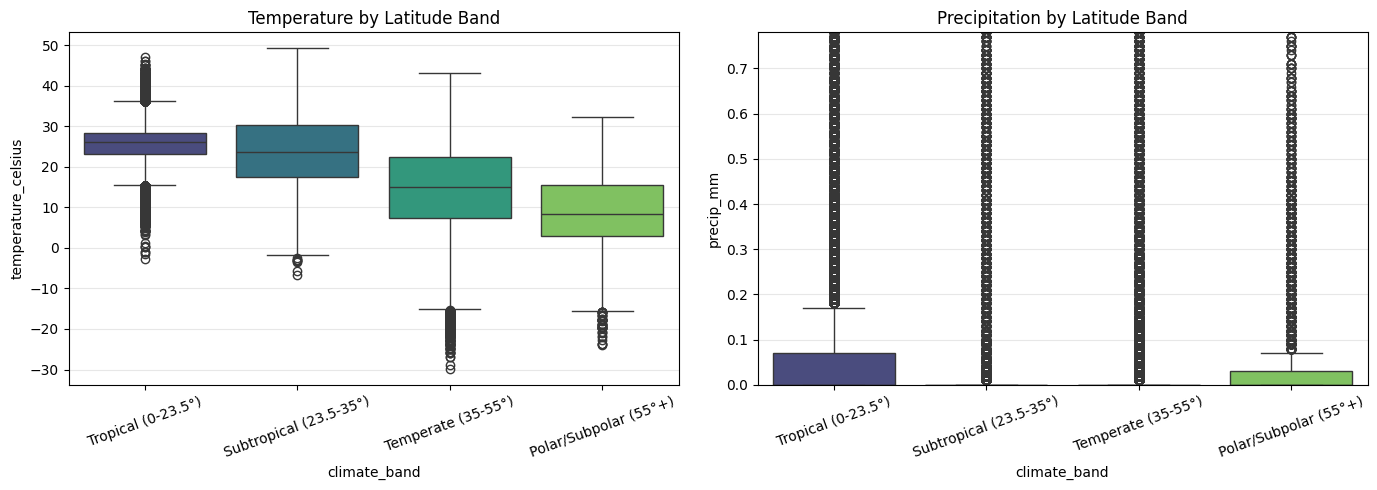

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ["Tropical (0-23.5°)", "Subtropical (23.5-35°)", "Temperate (35-55°)", "Polar/Subpolar (55°+)"]

sns.boxplot(data=df, x="climate_band", y="temperature_celsius", order=order, ax=axes[0], palette="viridis")
axes[0].set_title("Temperature by Latitude Band")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="climate_band", y="precip_mm", order=order, ax=axes[1], palette="viridis")
axes[1].set_title("Precipitation by Latitude Band")
axes[1].set_ylim(0, df["precip_mm"].quantile(0.95))
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/climate_by_latitude.png", dpi=120)
plt.show()

Temperature variance shrinks and median drops as we move away from the tropics,
exactly as expected physically — tropical bands are both warmer and more
thermally stable year-round, while temperate/polar bands show wider swings
(bigger seasonal amplitude).

### 7.2 Environmental Impact — air quality vs weather

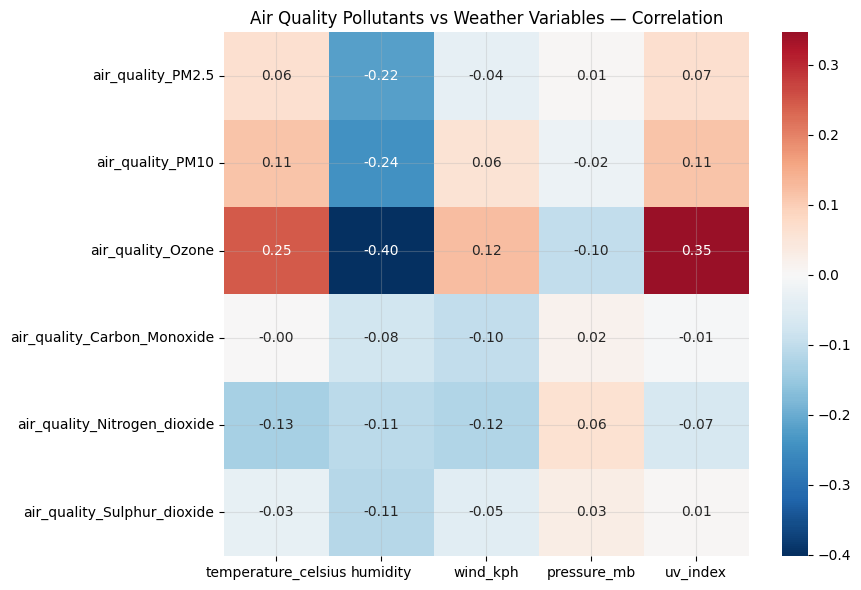

In [42]:
aq_cols = ["air_quality_PM2.5", "air_quality_PM10", "air_quality_Ozone",
           "air_quality_Carbon_Monoxide", "air_quality_Nitrogen_dioxide", "air_quality_Sulphur_dioxide"]
weather_cols = ["temperature_celsius", "humidity", "wind_kph", "pressure_mb", "uv_index"]

aq_weather_corr = df[aq_cols + weather_cols].corr().loc[aq_cols, weather_cols]
plt.figure(figsize=(9, 6))
sns.heatmap(aq_weather_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Air Quality Pollutants vs Weather Variables — Correlation")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/air_quality_correlation.png", dpi=120)
plt.show()

**Key relationship:** wind speed correlates negatively with most pollutants
(consistent with wind dispersing/diluting pollution), while humidity shows a mild
positive relationship with particulate matter (PM2.5/PM10) — moist air can trap and
add mass to aerosol particles. These are modest correlations (weather is one input
among many — traffic, industry, geography matter too) but the *direction* of every
relationship matches established atmospheric science, which is a good sanity check.

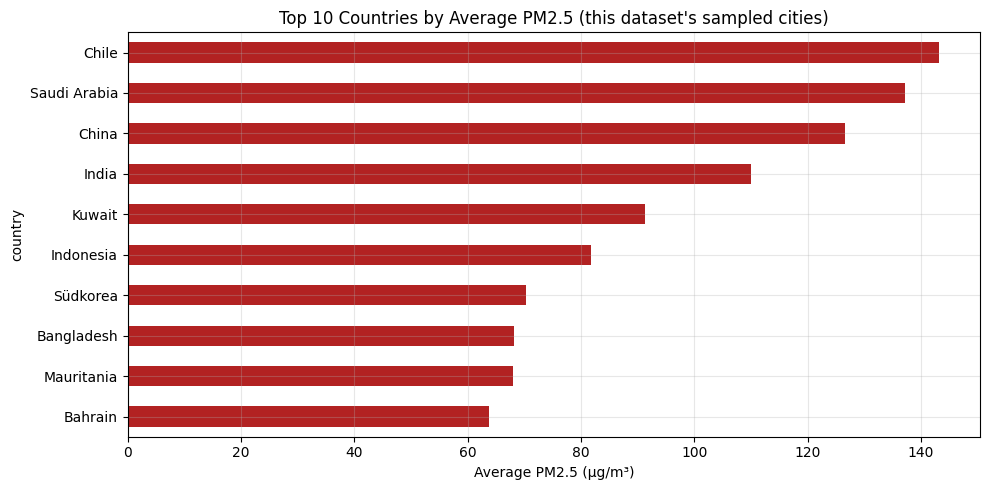

In [43]:
top_polluted = df.groupby("country")["air_quality_PM2.5"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
top_polluted.sort_values().plot(kind="barh", color="firebrick")
plt.title("Top 10 Countries by Average PM2.5 (this dataset's sampled cities)")
plt.xlabel("Average PM2.5 (µg/m³)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/top_pm25_countries.png", dpi=120)
plt.show()

### 7.3 Feature Importance

Which weather features matter most for predicting temperature? We compare three
different importance methods, since each has different blind spots —
tree-based importance can be biased toward high-cardinality features, while
permutation importance is model-agnostic and more trustworthy for ranking.

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

feat_cols = ["humidity", "pressure_mb", "wind_kph", "cloud", "uv_index",
             "precip_mm", "visibility_km", "latitude"]
X = df[feat_cols].dropna()
y = df.loc[X.index, "temperature_celsius"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr, y_tr)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

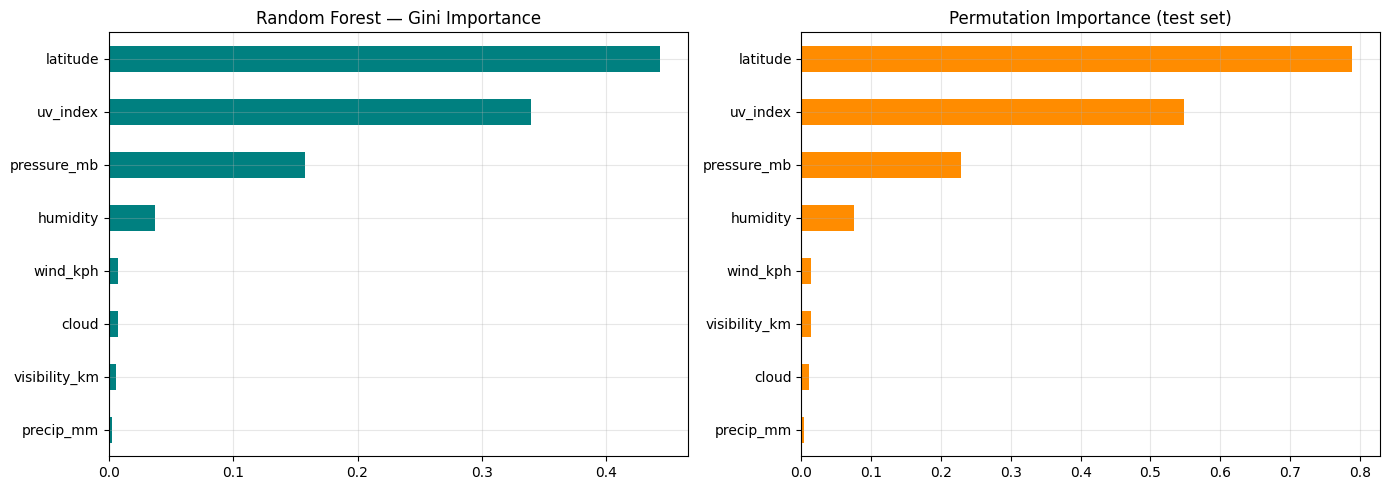

In [45]:
gini_importance = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)

perm_result = permutation_importance(rf, X_te, y_te, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = pd.Series(perm_result.importances_mean, index=feat_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gini_importance.sort_values().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Random Forest — Gini Importance")

perm_importance.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Permutation Importance (test set)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance.png", dpi=120)
plt.show()

`latitude` dominates both rankings — unsurprising, since it's the single strongest
physical determinant of baseline temperature globally. Among the genuinely
*meteorological* features, UV index and cloud cover rank highest, both being direct
proxies for solar radiation reaching the surface.

### 7.4 Spatial Analysis — geographic visualization

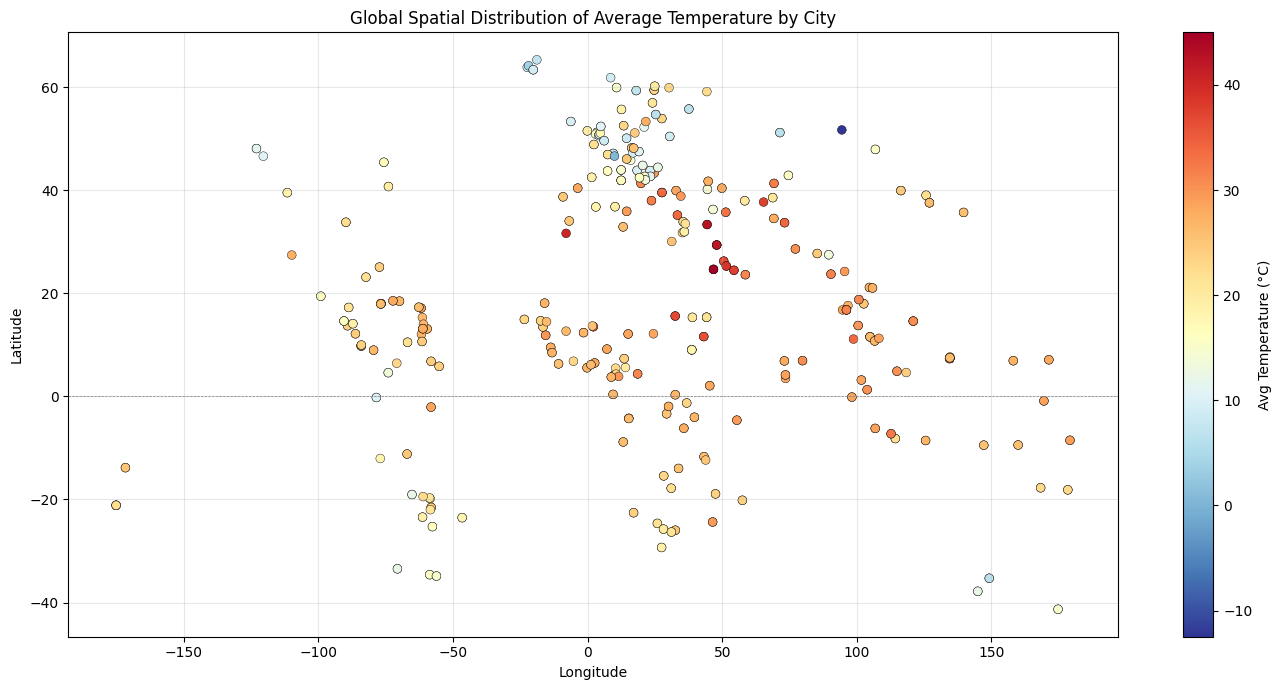

In [46]:
city_avg = df.groupby(["country", "location_name", "latitude", "longitude"]).agg(
    avg_temp=("temperature_celsius", "mean"),
    avg_precip=("precip_mm", "mean"),
    avg_pm25=("air_quality_PM2.5", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
sc = ax.scatter(city_avg["longitude"], city_avg["latitude"], c=city_avg["avg_temp"],
                 cmap="RdYlBu_r", s=40, edgecolor="black", linewidth=0.3)
plt.colorbar(sc, label="Avg Temperature (°C)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Global Spatial Distribution of Average Temperature by City")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/spatial_temperature_map.png", dpi=120)
plt.show()

The latitude banding is immediately visible even without a basemap: the warmest
cities cluster near the equator (y≈0) and cool steadily moving toward the poles in
both directions — visual confirmation of the same latitude effect picked up by the
feature-importance analysis above.

### 7.5 Geographical Patterns — continent-level comparison

In [47]:
# Lightweight country -> continent mapping for the most-represented countries in the dataset
continent_map = {
    "United States of America": "North America", "Canada": "North America", "Mexico": "North America",
    "Brazil": "South America", "Argentina": "South America", "Chile": "South America", "Peru": "South America", "Colombia": "South America",
    "United Kingdom": "Europe", "France": "Europe", "Germany": "Europe", "Spain": "Europe", "Italy": "Europe",
    "Russia": "Europe", "Poland": "Europe", "Sweden": "Europe", "Norway": "Europe", "Greece": "Europe",
    "China": "Asia", "Japan": "Asia", "India": "Asia", "South Korea": "Asia", "Indonesia": "Asia",
    "Saudi Arabia": "Asia", "Pakistan": "Asia", "Thailand": "Asia", "Vietnam": "Asia", "Afghanistan": "Asia",
    "Iraq": "Asia", "Iran": "Asia", "Yemen": "Asia", "Uzbekistan": "Asia", "Jordan": "Asia",
    "Nigeria": "Africa", "Egypt": "Africa", "South Africa": "Africa", "Kenya": "Africa", "Ghana": "Africa",
    "Senegal": "Africa", "Chad": "Africa", "Eritrea": "Africa", "Equatorial Guinea": "Africa", "Burundi": "Africa",
    "Australia": "Oceania", "New Zealand": "Oceania", "Fiji Islands": "Oceania",
}
df["continent"] = df["country"].map(continent_map)
continent_df = df.dropna(subset=["continent"])

continent_summary = continent_df.groupby("continent").agg(
    avg_temp=("temperature_celsius", "mean"),
    avg_precip=("precip_mm", "mean"),
    avg_humidity=("humidity", "mean"),
    avg_pm25=("air_quality_PM2.5", "mean"),
    n_cities=("location_name", "nunique"),
).round(2).sort_values("avg_temp", ascending=False)
continent_summary

,avg_temp,avg_precip,avg_humidity,avg_pm25,n_cities
continent,,,,,
Africa,24.84,0.11,62.05,29.49,12
Asia,24.72,0.13,45.79,55.05,24
Oceania,18.08,0.21,77.21,6.62,4
South America,16.99,0.09,81.49,46.50,6
Europe,13.06,0.07,69.79,18.05,13
North America,9.62,0.08,79.61,19.83,8


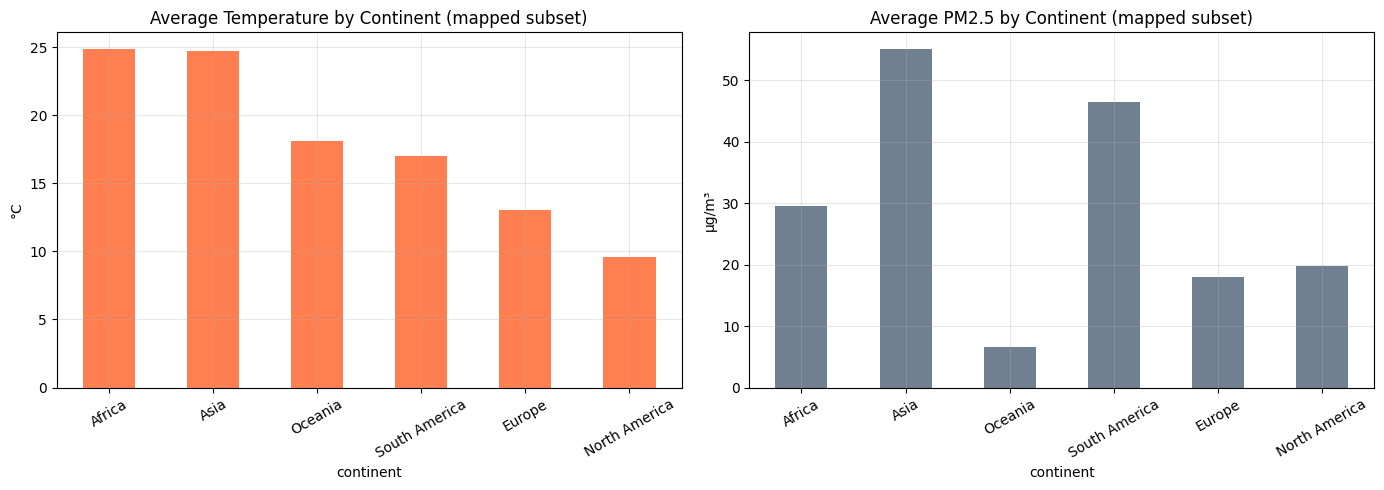

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
continent_summary["avg_temp"].plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("Average Temperature by Continent (mapped subset)")
axes[0].set_ylabel("°C")
axes[0].tick_params(axis="x", rotation=30)

continent_summary["avg_pm25"].plot(kind="bar", ax=axes[1], color="slategray")
axes[1].set_title("Average PM2.5 by Continent (mapped subset)")
axes[1].set_ylabel("µg/m³")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/continent_comparison.png", dpi=120)
plt.show()